# Estudio comparativo de la familia de algoritmos de Ascenso de Gradiente

## Introducción

¿Explicar un poco en qué consisten los algoritmos y qué es lo que se va a hacer en este estudio, indicando las distintas secciones en las que está dividido?

## Preparación del entorno

In [1]:
import sys, os

###  Setup para la ejecución en Colab

In [1]:
# Clonar el repositorio

In [2]:
# Añadir los directorio fuentes al path de Python

### Setup para la ejecución en local

In [2]:
# Añadir el directorio src al path para importar los módulos
src_path = os.path.abspath(os.path.join(os.getcwd(), 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)
    
print(sys.path)

['C:\\Users\\Marta\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip', 'C:\\Users\\Marta\\AppData\\Local\\Programs\\Python\\Python312\\DLLs', 'C:\\Users\\Marta\\AppData\\Local\\Programs\\Python\\Python312\\Lib', 'C:\\Users\\Marta\\AppData\\Local\\Programs\\Python\\Python312', 'c:\\Users\\Marta\\Documents\\Mis_archivos\\Universidad\\Master\\2_cuatri\\Extensiones_ML\\eml-venv', '', 'c:\\Users\\Marta\\Documents\\Mis_archivos\\Universidad\\Master\\2_cuatri\\Extensiones_ML\\eml-venv\\Lib\\site-packages', 'c:\\Users\\Marta\\Documents\\Mis_archivos\\Universidad\\Master\\2_cuatri\\Extensiones_ML\\EML_RL_LucasOrtiz\\k_brazos\\src']


### Importación de librerías y módulos

In [3]:
import numpy as np

from algorithms import Softmax, PreferenceGradient
from arms import Bandit, ArmNormal, ArmBinomial, ArmBernoulli
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics
from run_experiment import run_experiment

## Parámetros generales

blablabla

In [4]:
SEMILLA = 1024

k = 6  # Número de brazos
steps = 300  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

## Creación de los bandidos

Distribución normal

In [5]:
# Creación del bandit
np.random.seed(SEMILLA)
bandit_normal = Bandit(arms=ArmNormal.generate_arms(k, mu_min=5, mu_max=10)) # Generar un bandido con k brazos de distribución normal
print(bandit_normal)

optimal_arm_normal = bandit_normal.optimal_arm
print(f"Optimal arm: {optimal_arm_normal + 1} with expected reward={bandit_normal.get_expected_value(optimal_arm_normal)}")

Bandit with 6 arms: ArmNormal(mu=7.59, sigma=1.27), ArmNormal(mu=8.24, sigma=1.01), ArmNormal(mu=9.98, sigma=1.3), ArmNormal(mu=8.0, sigma=2.4), ArmNormal(mu=8.29, sigma=2.19), ArmNormal(mu=8.77, sigma=2.8)
Optimal arm: 3 with expected reward=9.98


Distribución binomial

In [6]:
# Creación del bandit
np.random.seed(SEMILLA)
bandit_binomial = Bandit(arms=ArmBinomial.generate_arms(k, n_min=5, n_max=15)) # Generar un bandido con k brazos de distribución binomial
print(bandit_binomial)

optimal_arm_binomial = bandit_binomial.optimal_arm
print(f"Optimal arm: {optimal_arm_binomial + 1} with expected reward={bandit_binomial.get_expected_value(optimal_arm_binomial)}")

Bandit with 6 arms: ArmBinomial(n=6, p=0.58), ArmBinomial(n=6, p=0.7), ArmBinomial(n=10, p=0.22), ArmBinomial(n=14, p=0.21), ArmBinomial(n=6, p=0.1), ArmBinomial(n=5, p=0.66)
Optimal arm: 2 with expected reward=4.199999999999999


Distribución bernoulli

In [7]:
# Creación del bandit
np.random.seed(SEMILLA)
bandit_bernoulli = Bandit(arms=ArmBernoulli.generate_arms(k)) # Generar un bandido con k brazos de distribución Bernoulli
print(bandit_bernoulli)

optimal_arm_bernoulli = bandit_bernoulli.optimal_arm
print(f"Optimal arm: {optimal_arm_bernoulli + 1} with expected reward={bandit_bernoulli.get_expected_value(optimal_arm_bernoulli)}")

Bandit with 6 arms: ArmBernoulli(p=0.62), ArmBernoulli(p=0.9), ArmBernoulli(p=0.63), ArmBernoulli(p=0.58), ArmBernoulli(p=0.52), ArmBernoulli(p=0.7)
Optimal arm: 2 with expected reward=0.9


## Análisis de Softmax

In [8]:
algorithms_softmax = [Softmax(k=k, temp=1), Softmax(k=k, temp=0.5), Softmax(k=k, temp=2)] 

### Distribución Normal

In [9]:
np.random.seed(SEMILLA)
rewards_SN, optimal_selections_SN, cumulative_regret_per_algo_SN, rewards_per_arm_per_algo_SN = run_experiment(bandit_normal, algorithms_softmax, steps, runs)

100%|██████████| 500/500 [00:26<00:00, 18.88it/s]


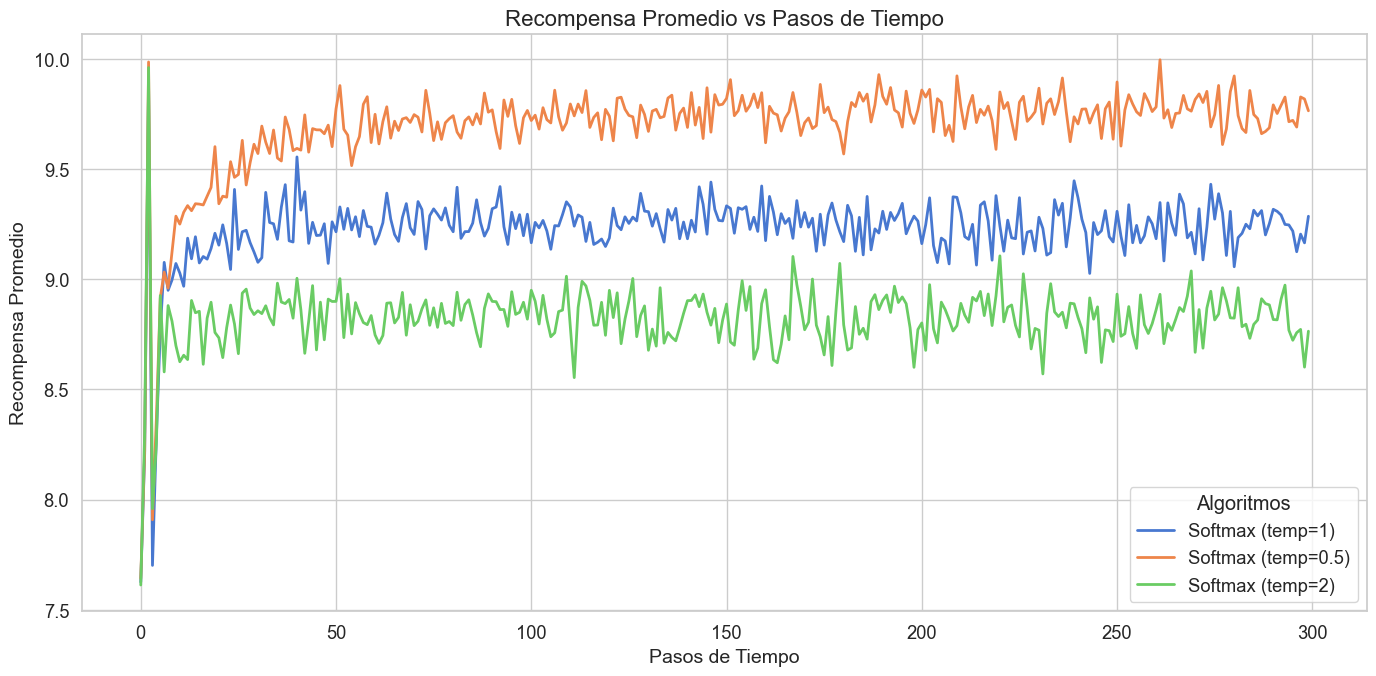

In [10]:
plot_average_rewards(steps, rewards_SN, algorithms_softmax)

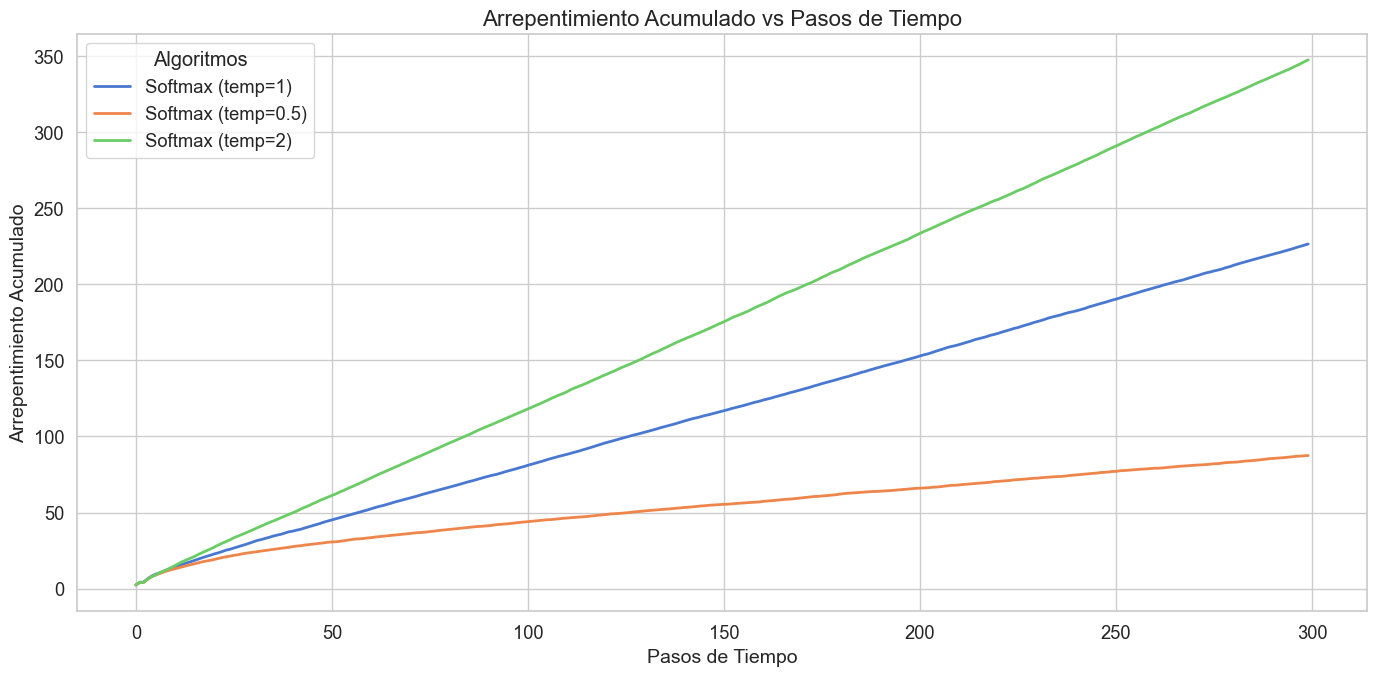

In [11]:
plot_regret(steps, cumulative_regret_per_algo_SN, algorithms_softmax)

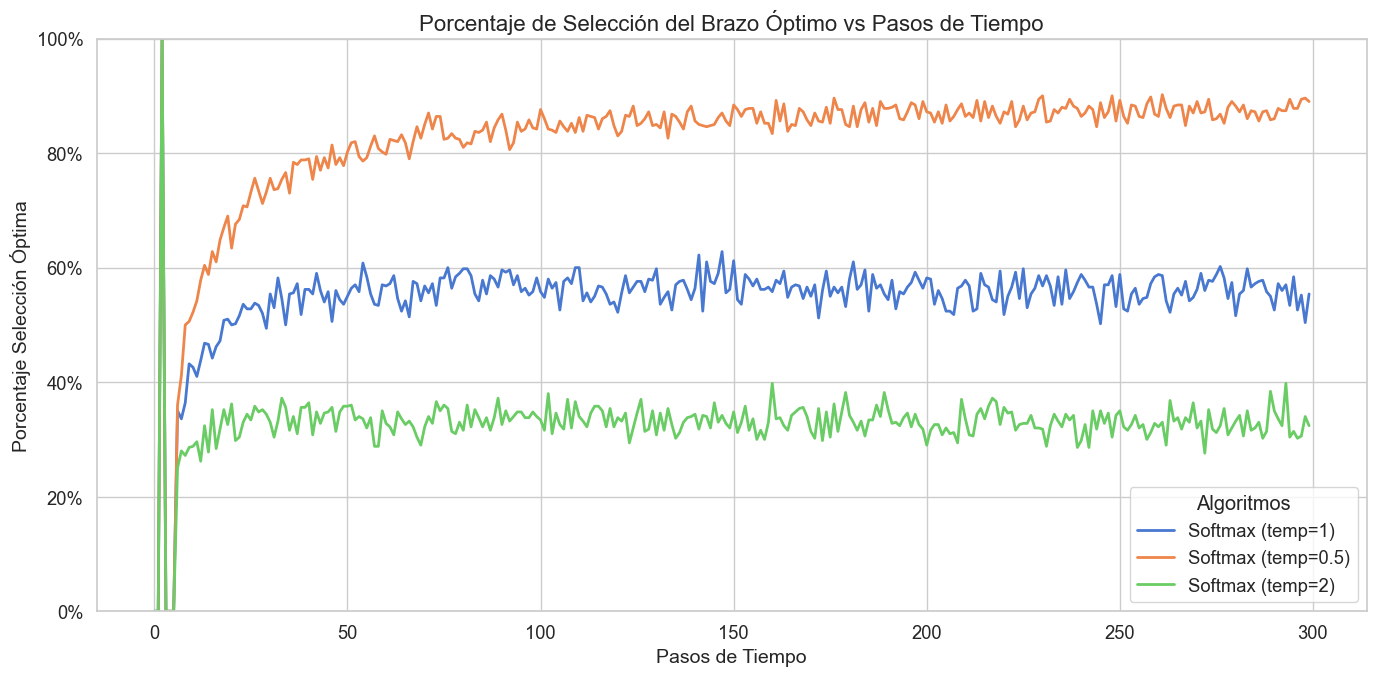

In [12]:
plot_optimal_selections(steps, optimal_selections_SN, algorithms_softmax)

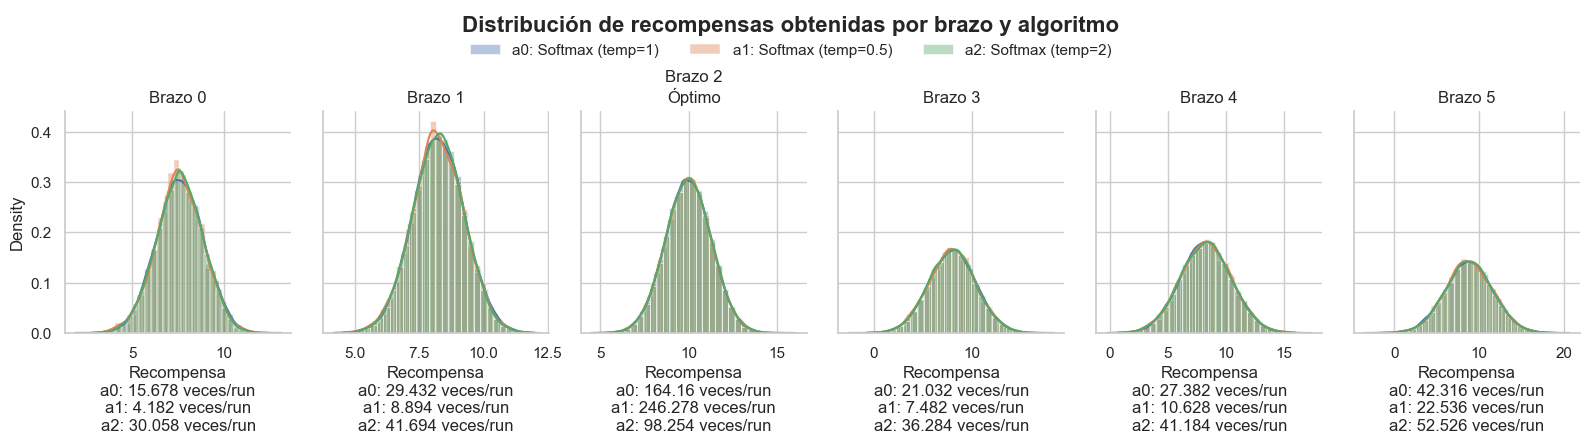

In [13]:
plot_arm_statistics(rewards_per_arm_per_algo_SN, algorithms_softmax, runs, optimal_arm_normal)

### Distribución Binomial

In [14]:
np.random.seed(SEMILLA)
rewards_SBi, optimal_selections_SBi, cumulative_regret_per_algo_SBi, rewards_per_arm_per_algo_SBi = run_experiment(bandit_binomial, algorithms_softmax, steps, runs)

100%|██████████| 500/500 [00:27<00:00, 18.05it/s]


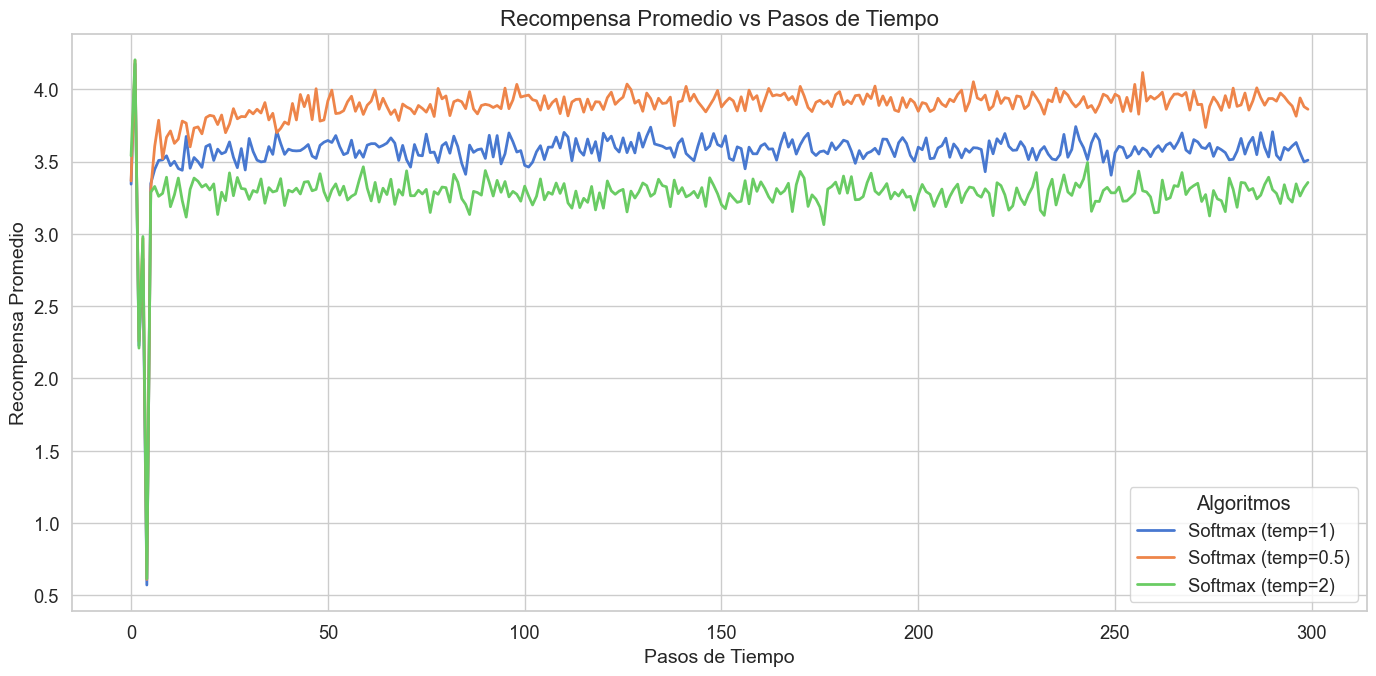

In [15]:
plot_average_rewards(steps, rewards_SBi, algorithms_softmax)

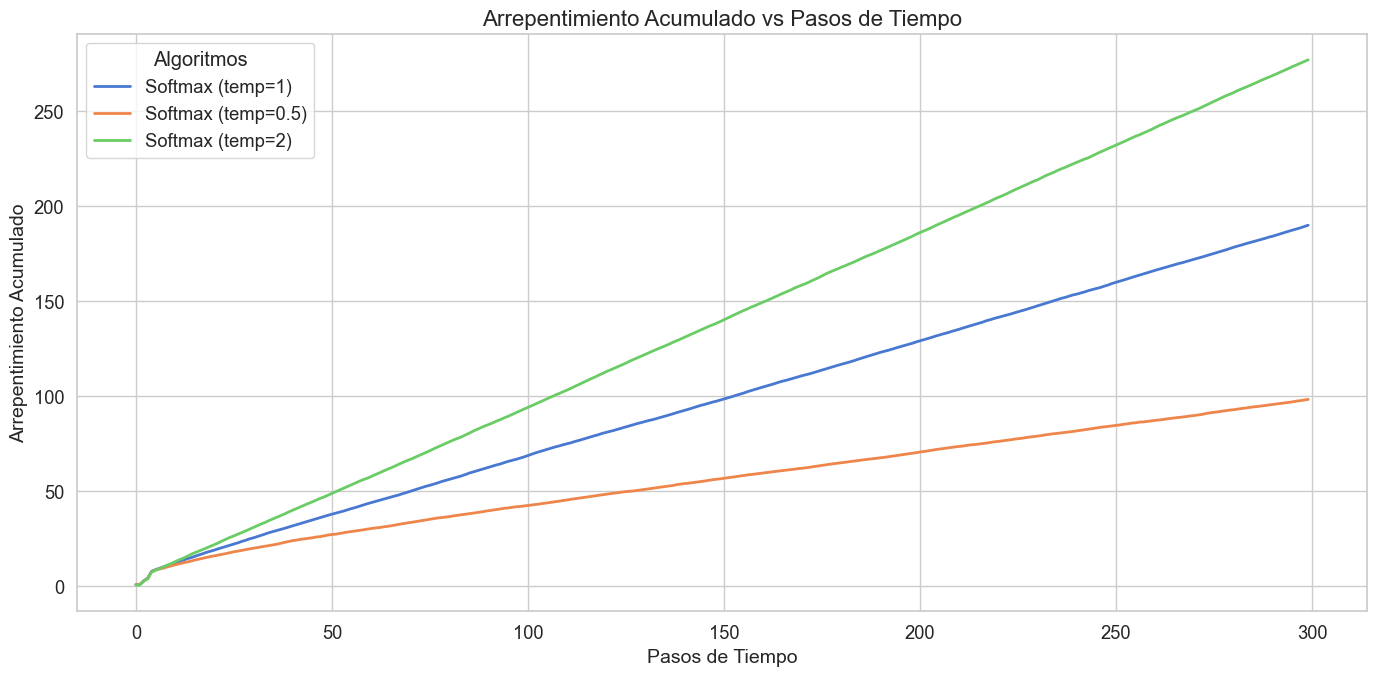

In [16]:
plot_regret(steps, cumulative_regret_per_algo_SBi, algorithms_softmax)

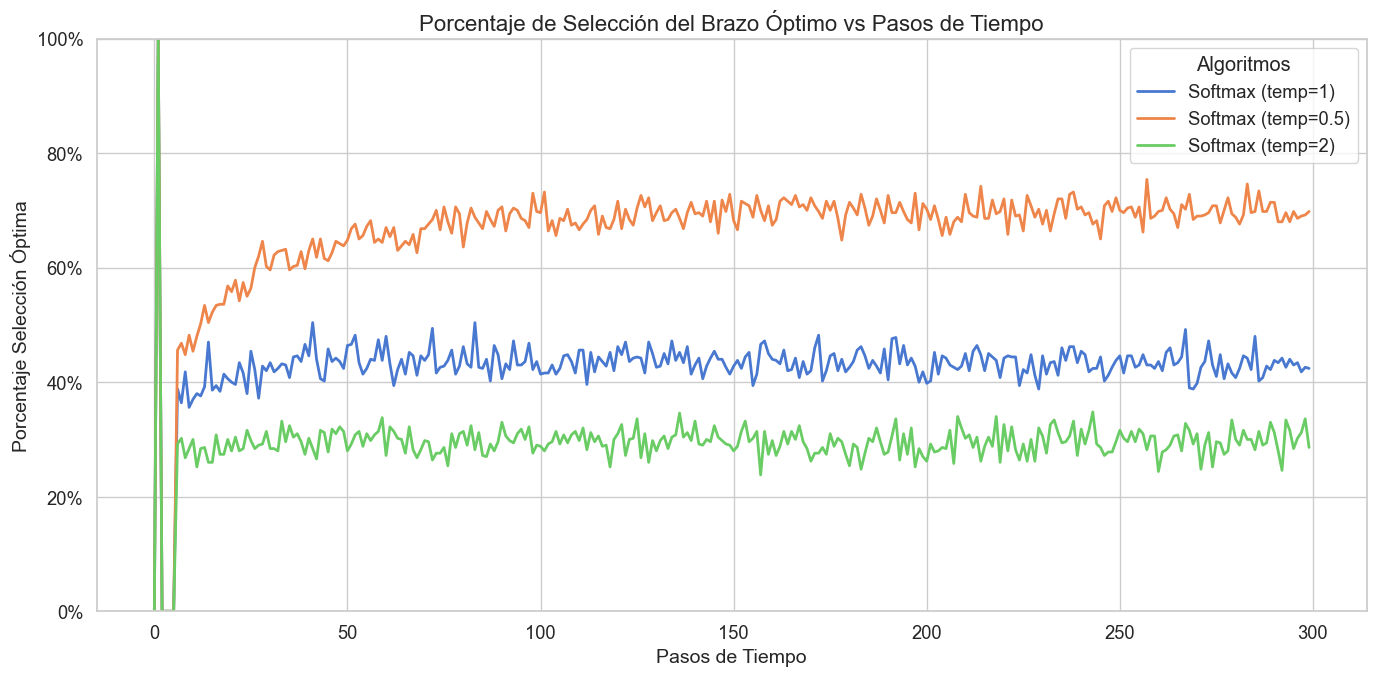

In [17]:
plot_optimal_selections(steps, optimal_selections_SBi, algorithms_softmax)

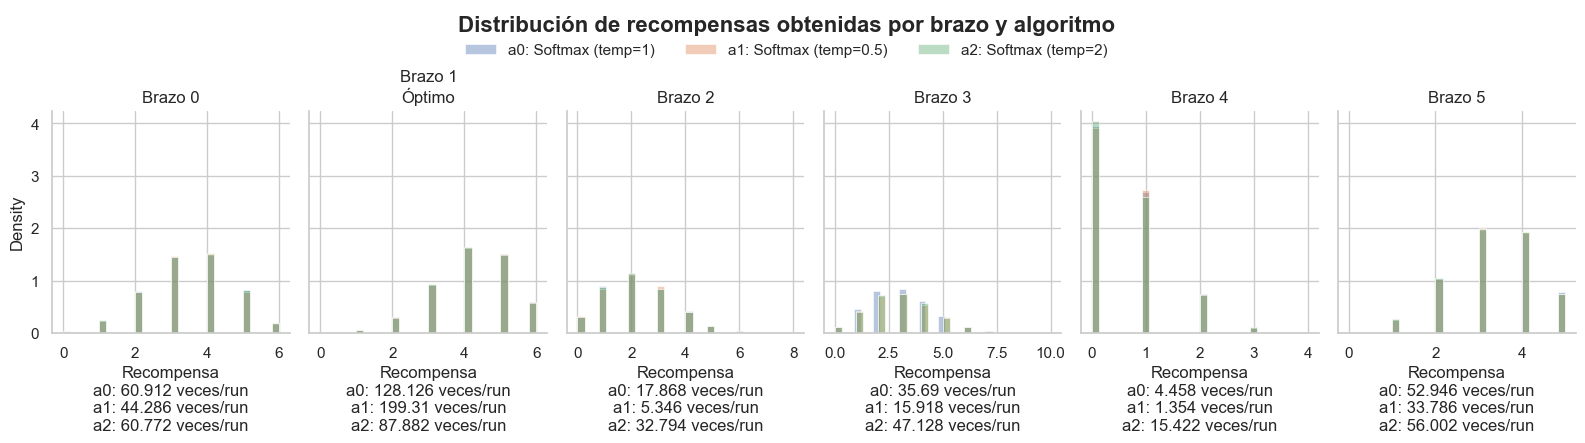

In [18]:
plot_arm_statistics(rewards_per_arm_per_algo_SBi, algorithms_softmax, runs, optimal_arm_binomial, kde=False)

### Distribución Bernoulli

In [19]:
np.random.seed(SEMILLA)
rewards_SBe, optimal_selections_SBe, cumulative_regret_per_algo_SBe, rewards_per_arm_per_algo_SBe = run_experiment(bandit_bernoulli, algorithms_softmax, steps, runs)

100%|██████████| 500/500 [00:26<00:00, 19.07it/s]


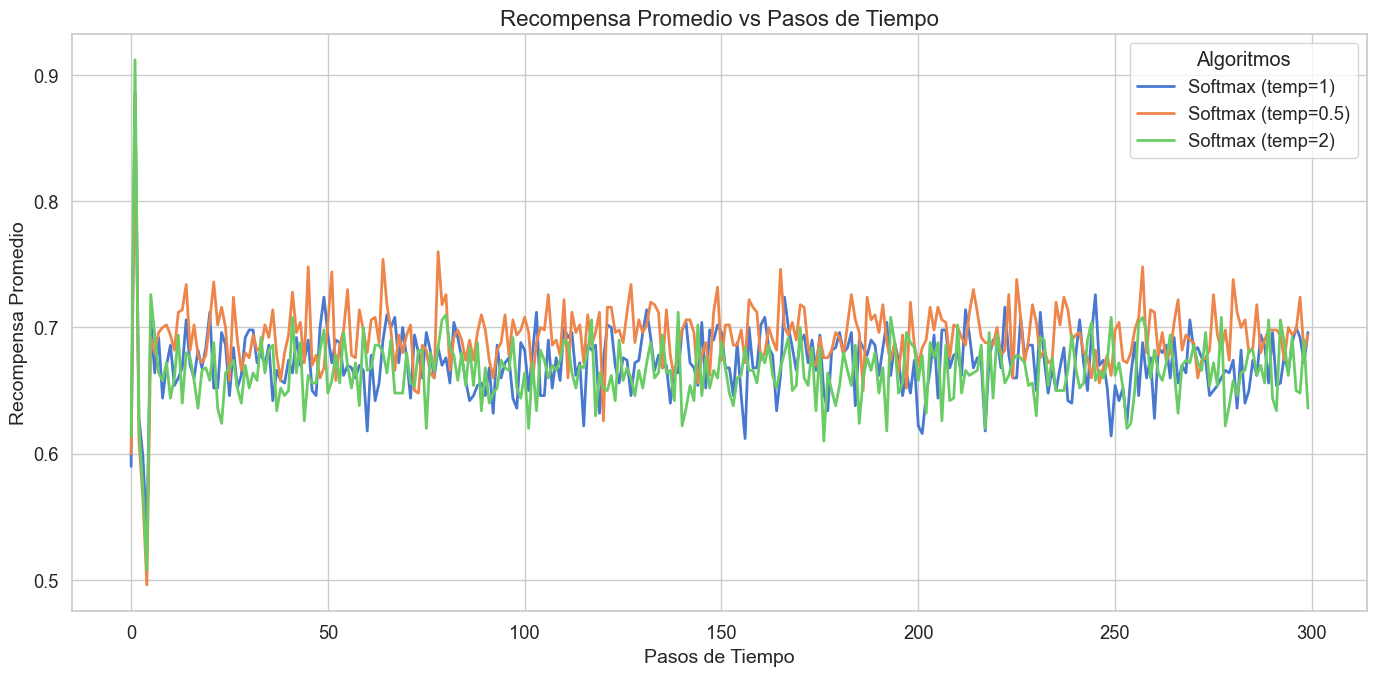

In [20]:
plot_average_rewards(steps, rewards_SBe, algorithms_softmax)

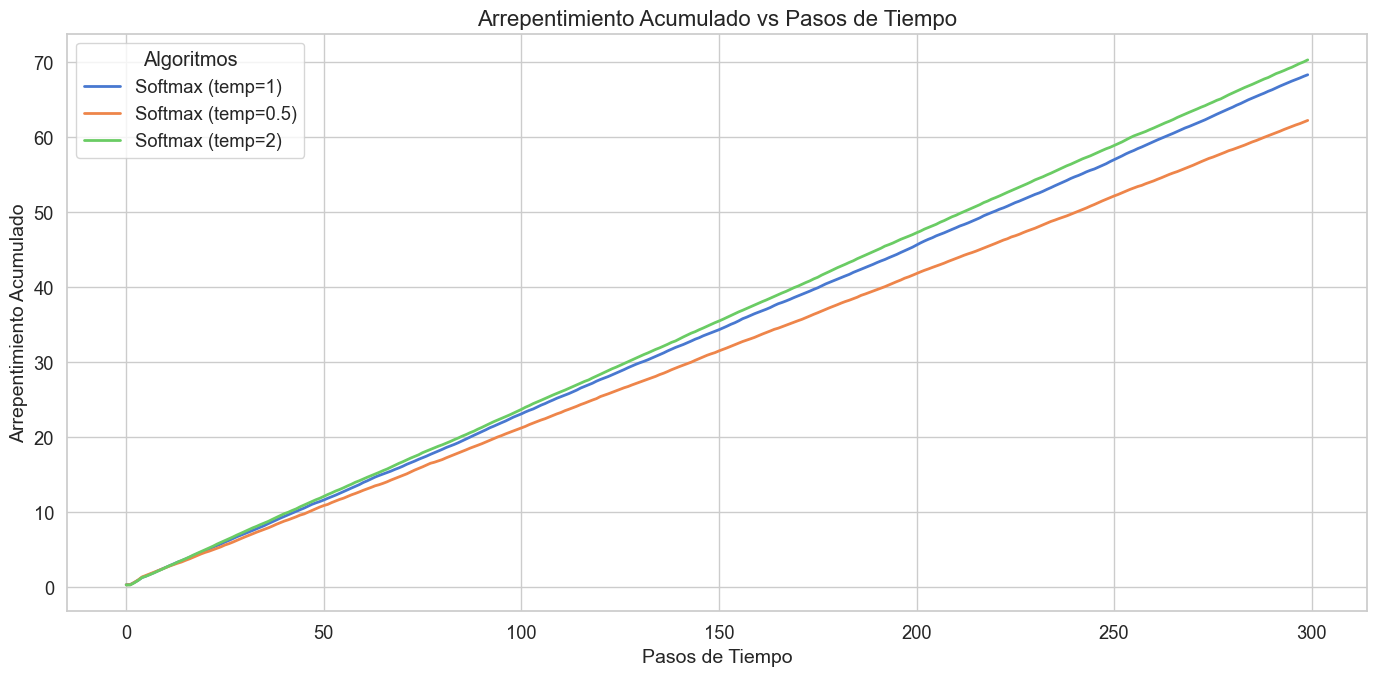

In [21]:
plot_regret(steps, cumulative_regret_per_algo_SBe, algorithms_softmax)

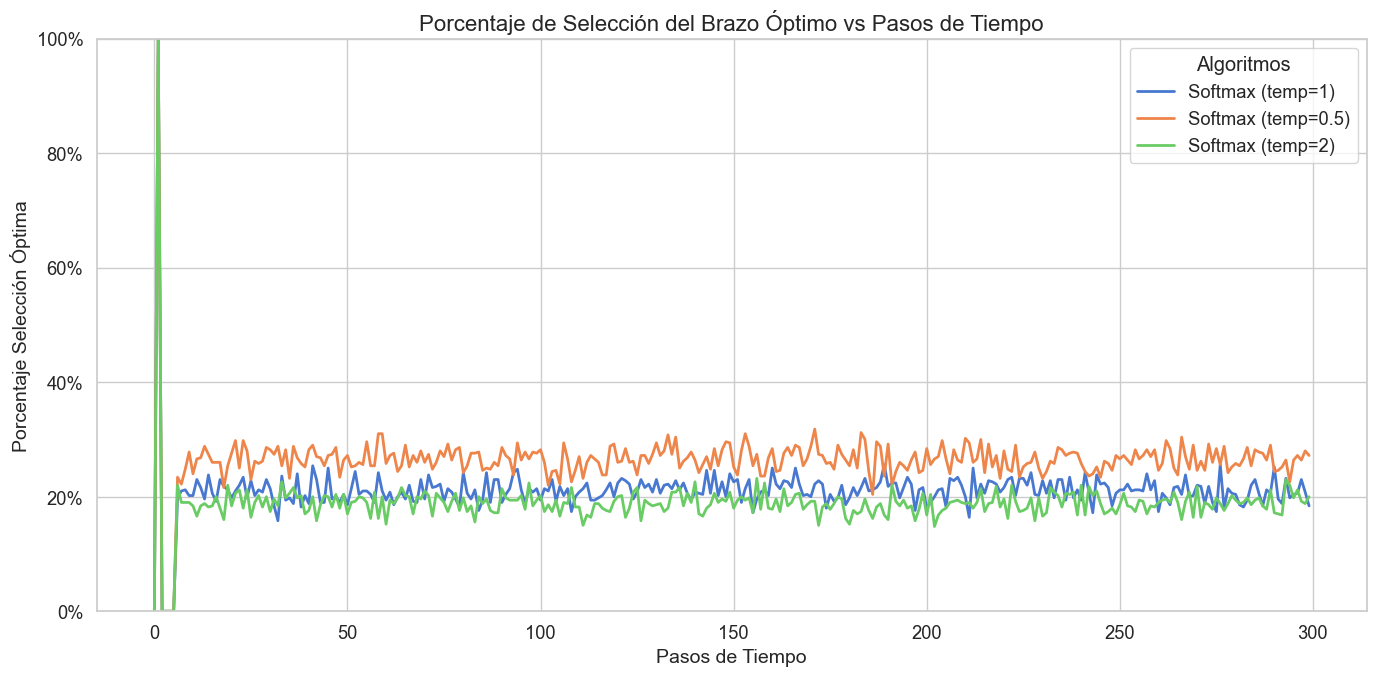

In [22]:
plot_optimal_selections(steps, optimal_selections_SBe, algorithms_softmax)

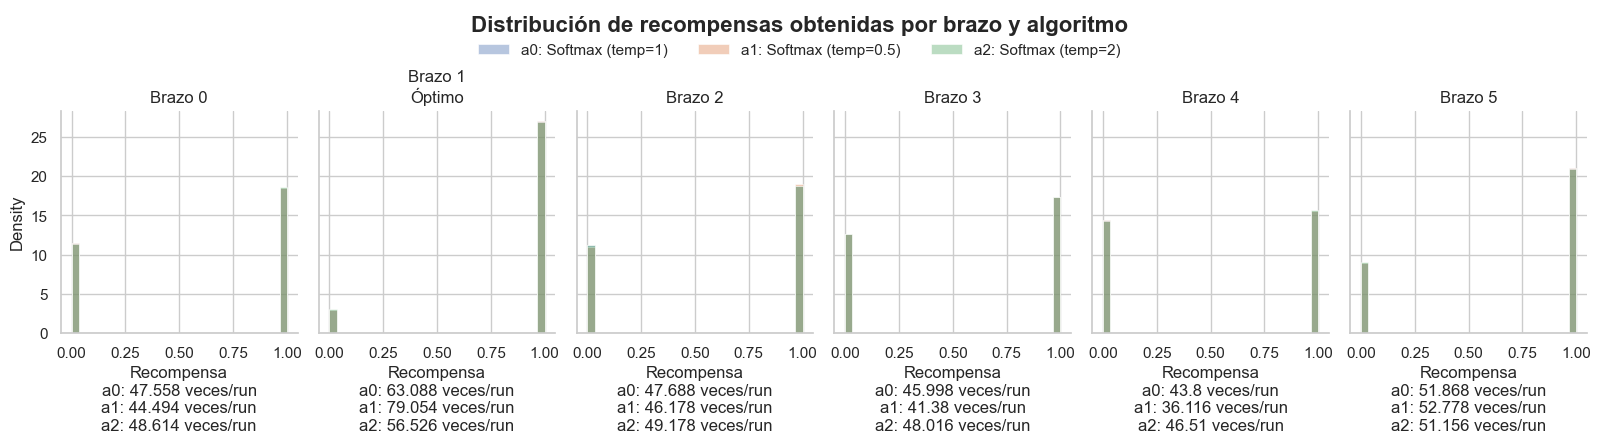

In [23]:
plot_arm_statistics(rewards_per_arm_per_algo_SBe, algorithms_softmax, runs, optimal_arm_bernoulli, kde=False)

## Análisis de Gradiente de Preferencias

In [24]:
algorithms_gradient = [PreferenceGradient(k=k, alpha=0.1), PreferenceGradient(k=k, alpha=0.4), PreferenceGradient(k=k, alpha=0.7)]

### Distribución Normal

In [25]:
np.random.seed(SEMILLA)
rewards_GN, optimal_selections_GN, cumulative_regret_per_algo_GN, rewards_per_arm_per_algo_GN = run_experiment(bandit_normal, algorithms_gradient, steps, runs)

100%|██████████| 500/500 [00:33<00:00, 14.76it/s]


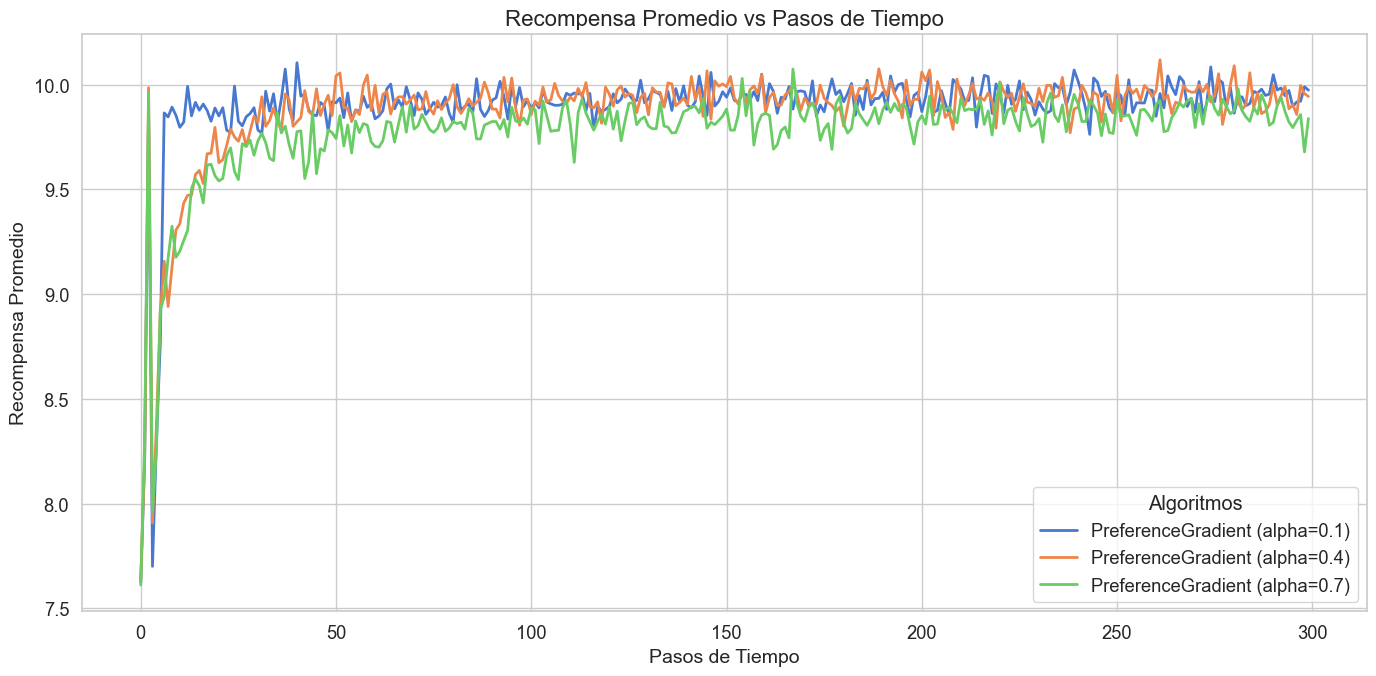

In [26]:
plot_average_rewards(steps, rewards_GN, algorithms_gradient)

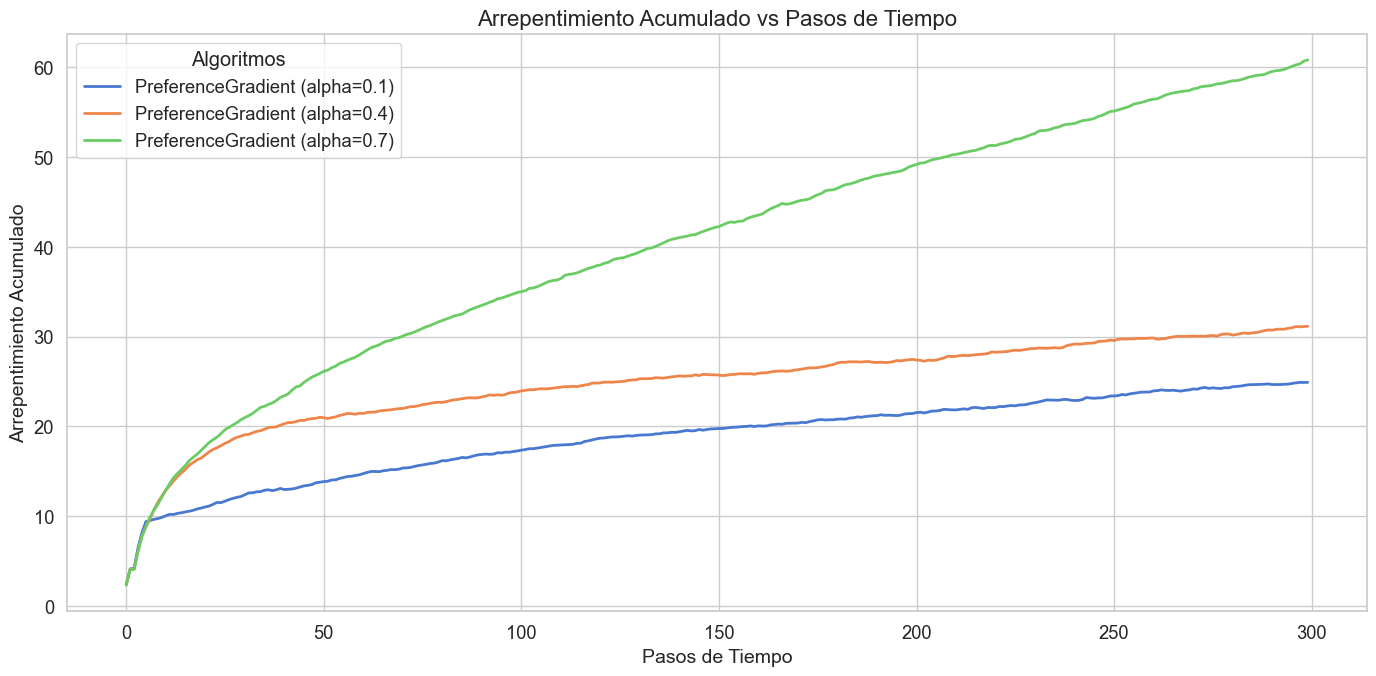

In [27]:
plot_regret(steps, cumulative_regret_per_algo_GN, algorithms_gradient)

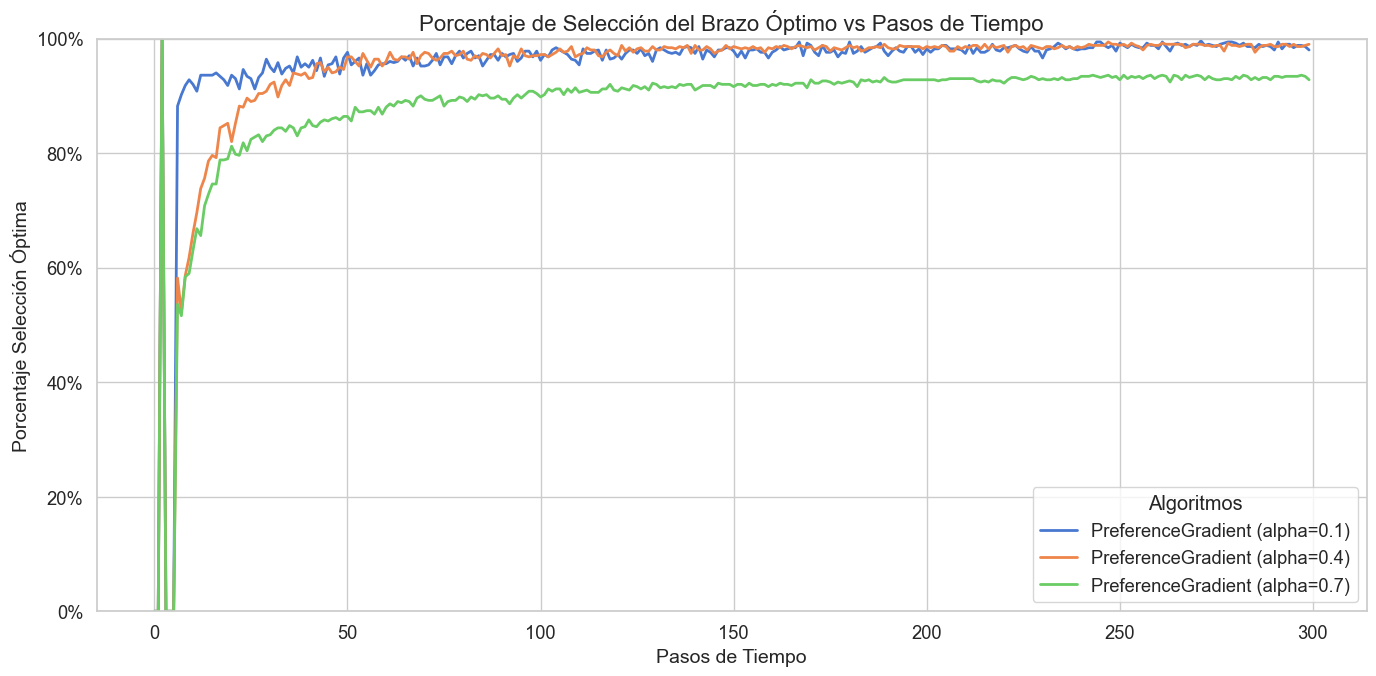

In [28]:
plot_optimal_selections(steps, optimal_selections_GN, algorithms_gradient)

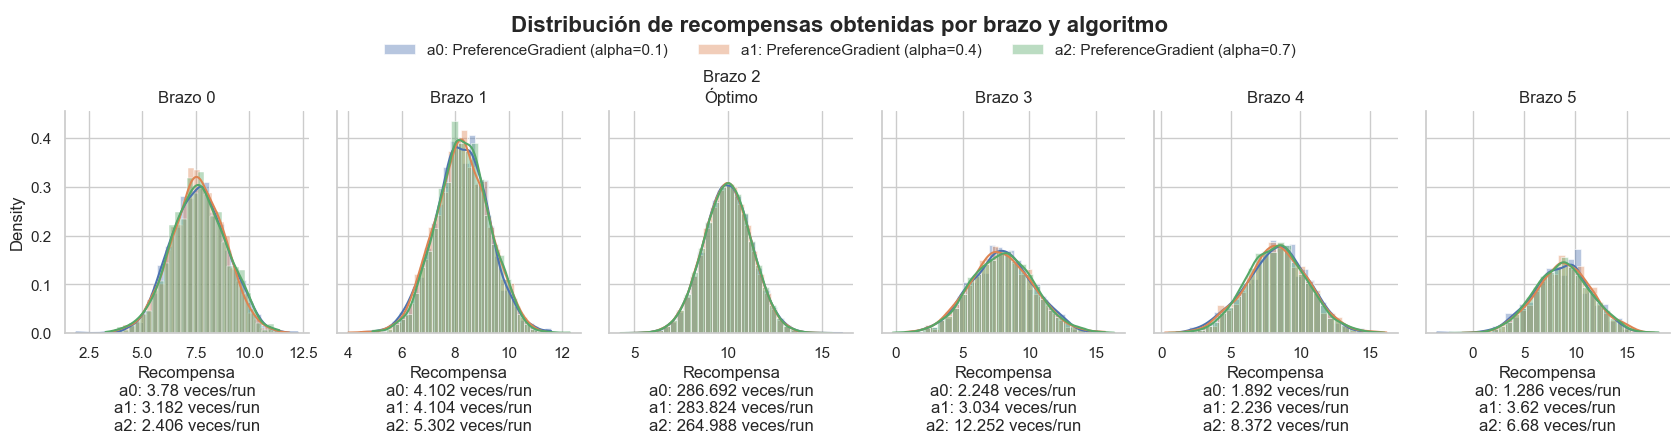

In [29]:
plot_arm_statistics(rewards_per_arm_per_algo_GN, algorithms_gradient, runs, optimal_arm_normal)

### Distribución Binomial

In [30]:
np.random.seed(SEMILLA)
rewards_GBi, optimal_selections_GBi, cumulative_regret_per_algo_GBi, rewards_per_arm_per_algo_GBi = run_experiment(bandit_binomial, algorithms_gradient, steps, runs)

100%|██████████| 500/500 [00:34<00:00, 14.54it/s]


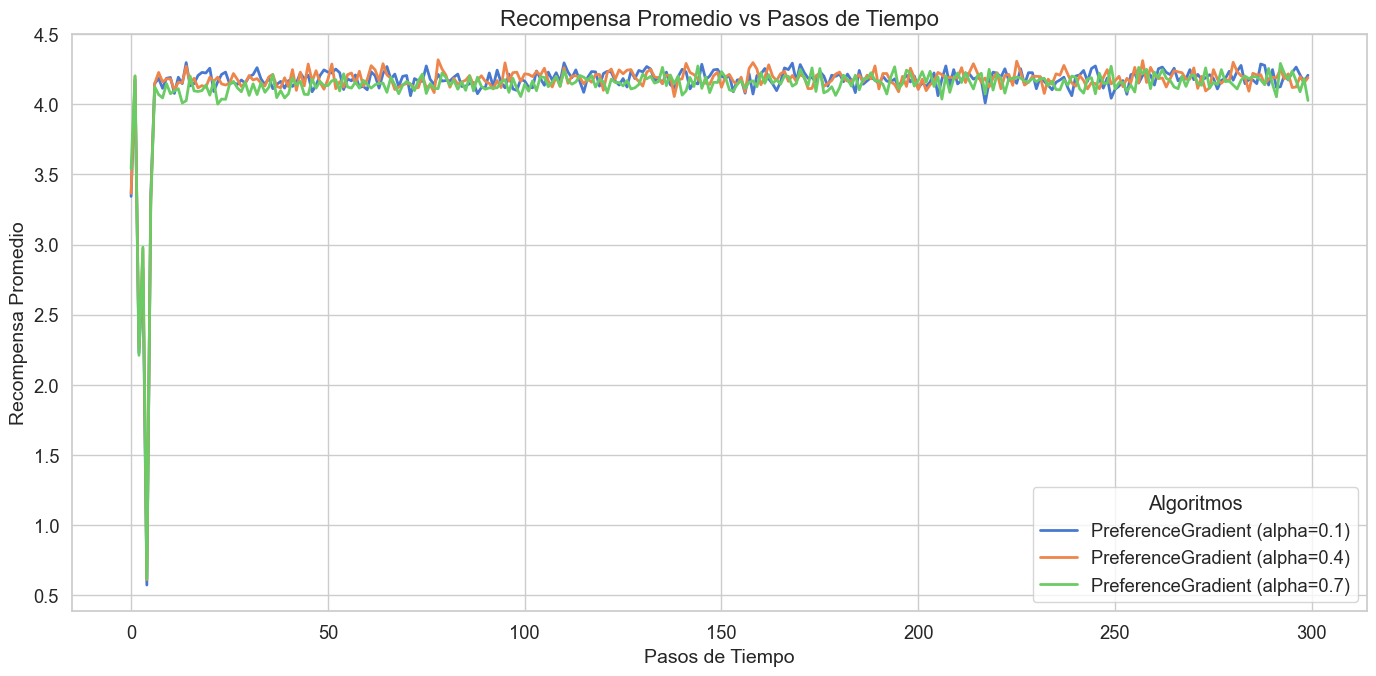

In [31]:
plot_average_rewards(steps, rewards_GBi, algorithms_gradient)

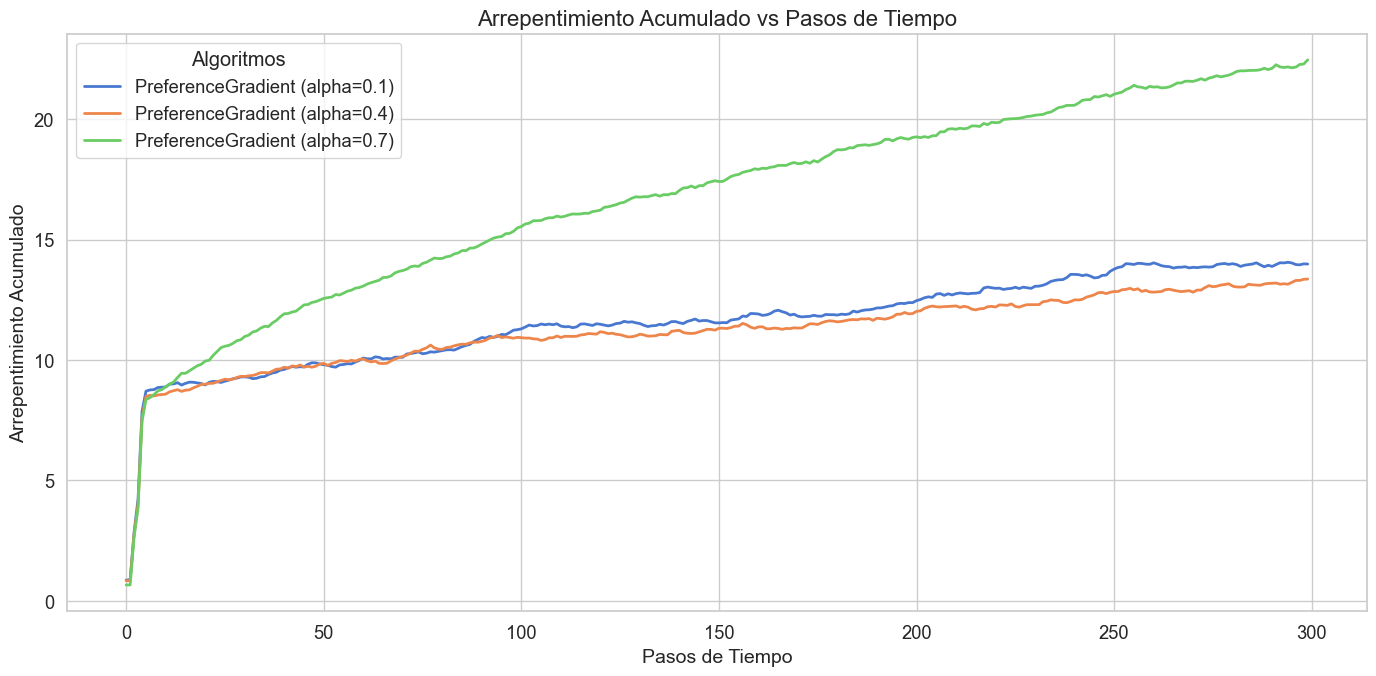

In [32]:
plot_regret(steps, cumulative_regret_per_algo_GBi, algorithms_gradient)

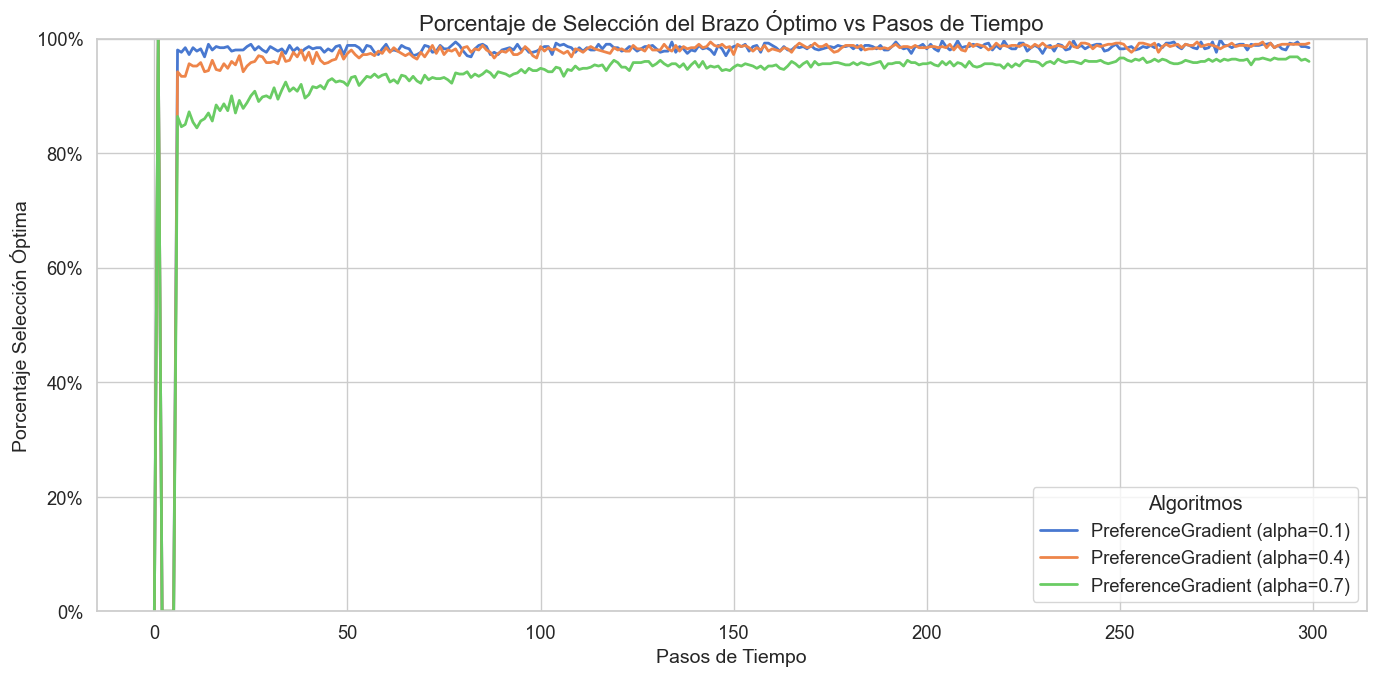

In [33]:
plot_optimal_selections(steps, optimal_selections_GBi, algorithms_gradient)

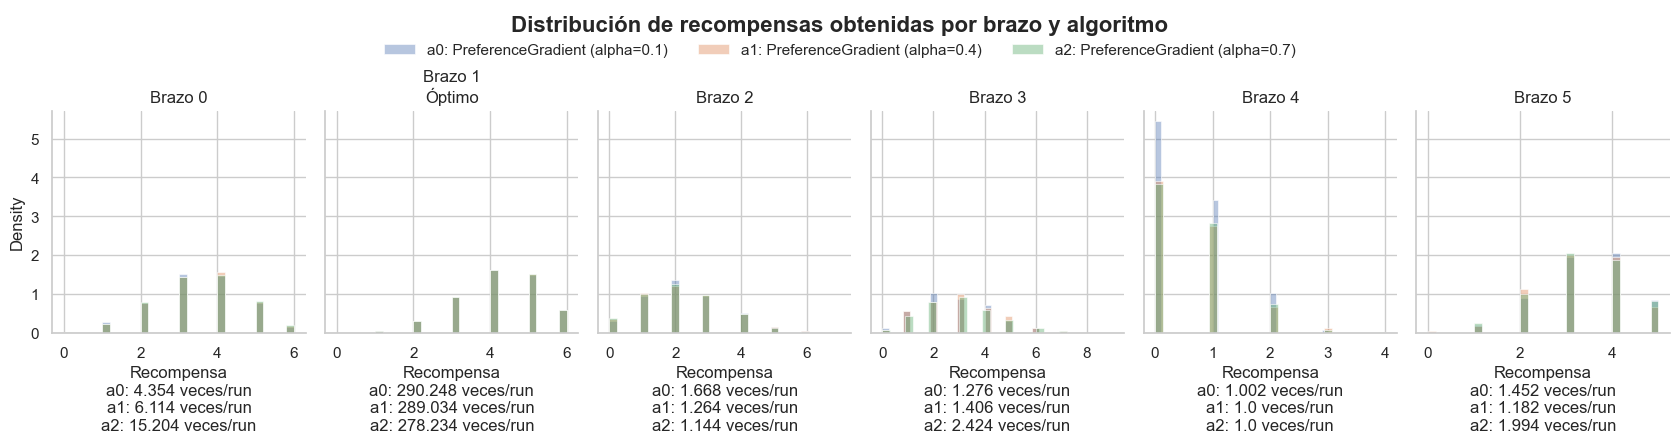

In [34]:
plot_arm_statistics(rewards_per_arm_per_algo_GBi, algorithms_gradient, runs, optimal_arm_binomial, kde=False)

### Distribución Bernoulli

In [35]:
np.random.seed(SEMILLA)
rewards_GBe, optimal_selections_GBe, cumulative_regret_per_algo_GBe, rewards_per_arm_per_algo_GBe = run_experiment(bandit_bernoulli, algorithms_gradient, steps, runs)

100%|██████████| 500/500 [00:33<00:00, 14.80it/s]


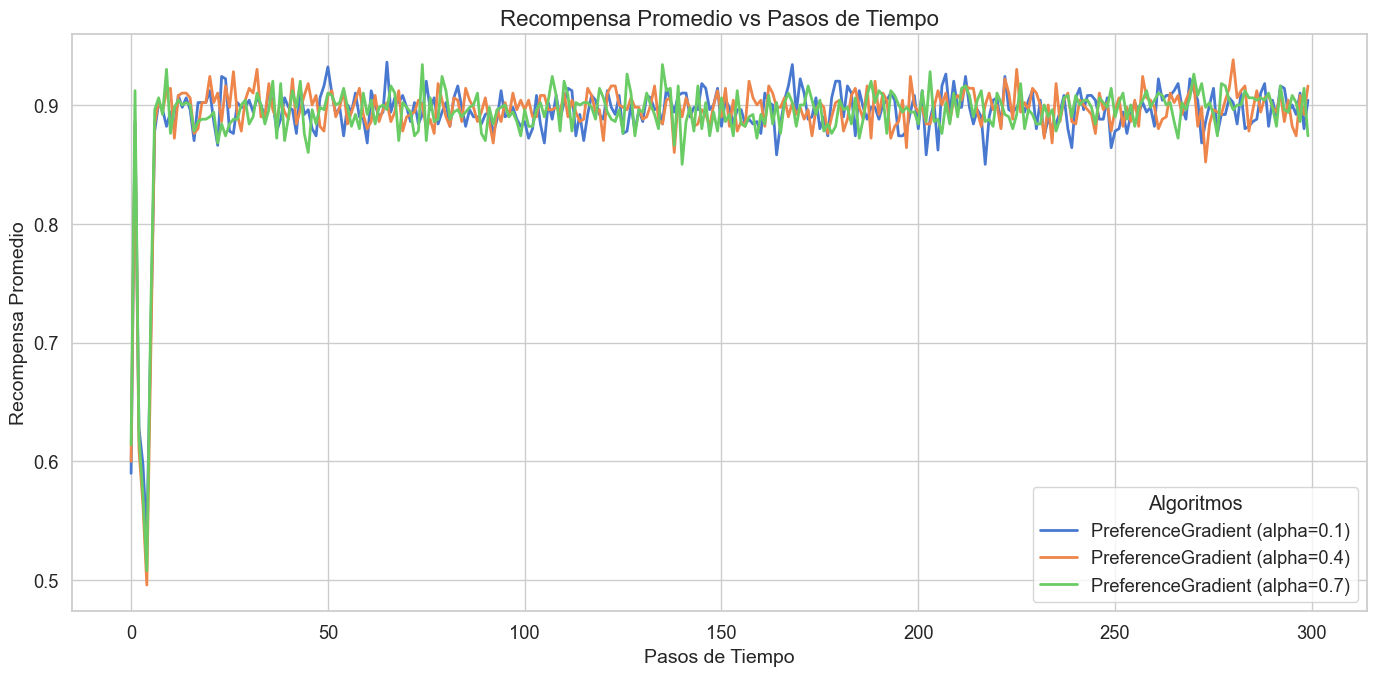

In [36]:
plot_average_rewards(steps, rewards_GBe, algorithms_gradient)

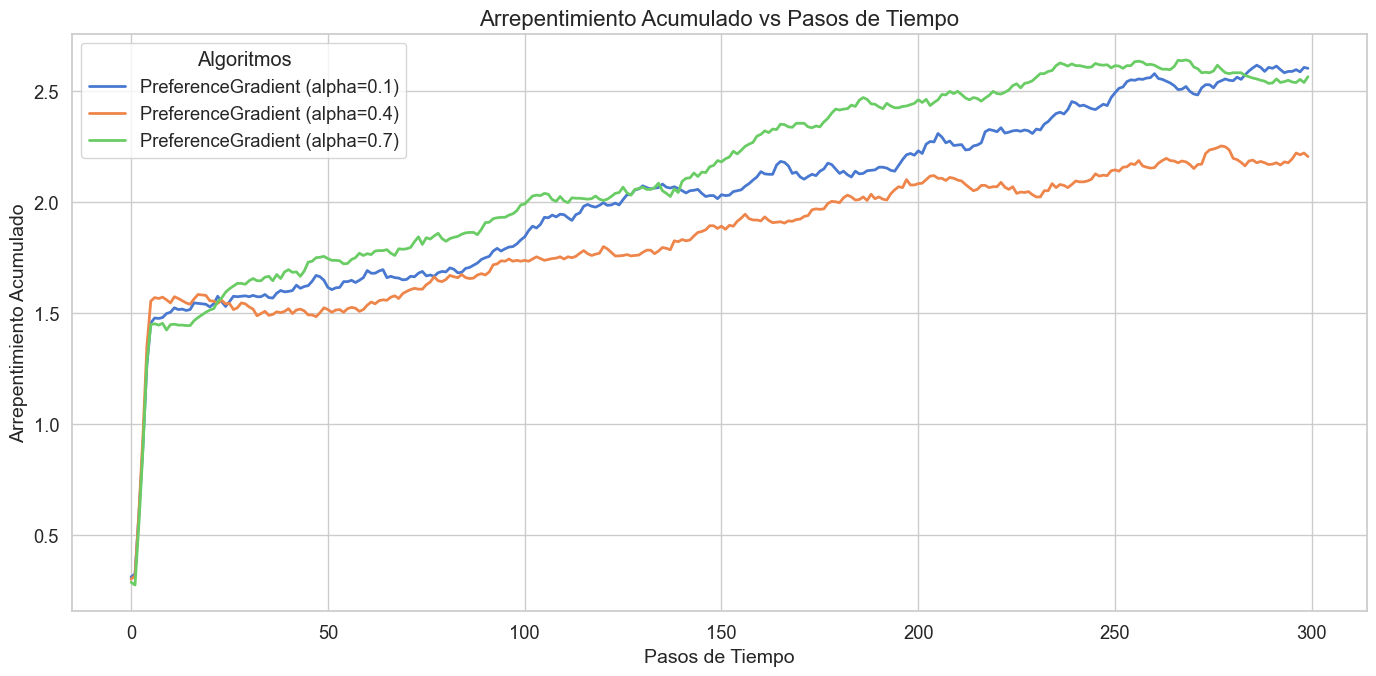

In [37]:
plot_regret(steps, cumulative_regret_per_algo_GBe, algorithms_gradient)

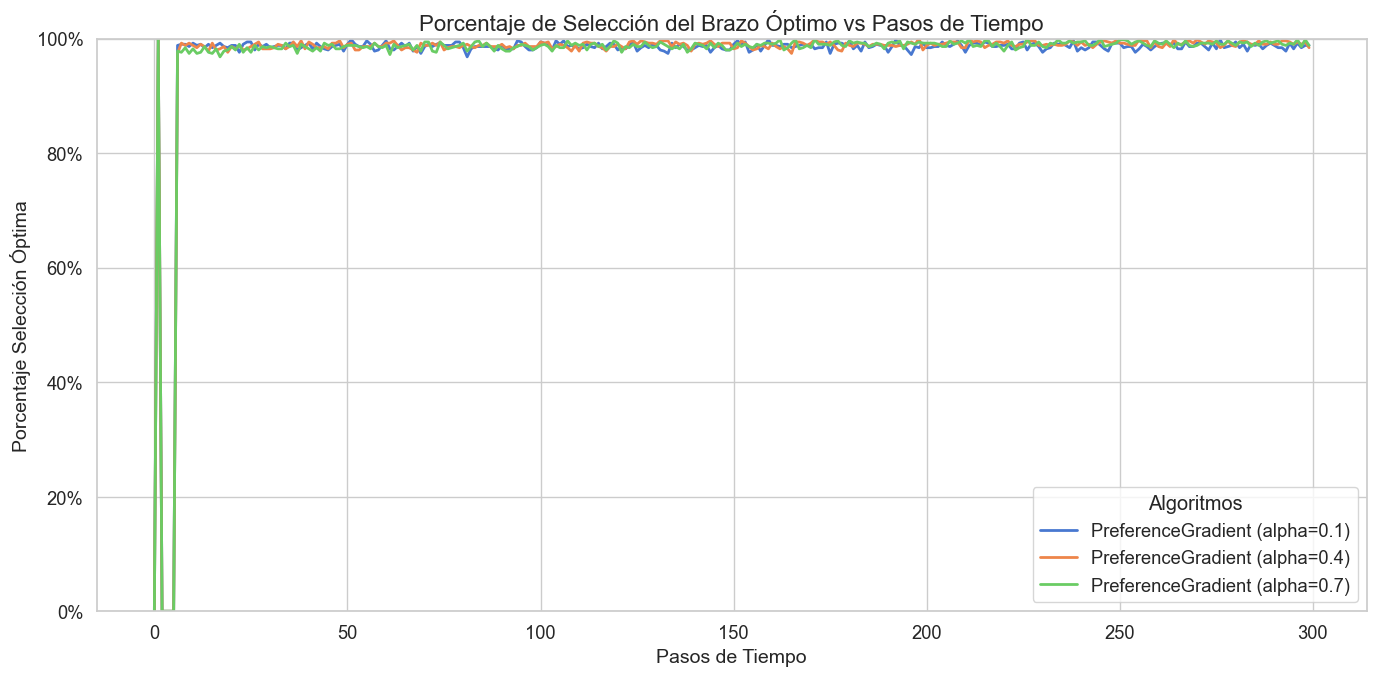

In [38]:
plot_optimal_selections(steps, optimal_selections_GBe, algorithms_gradient)

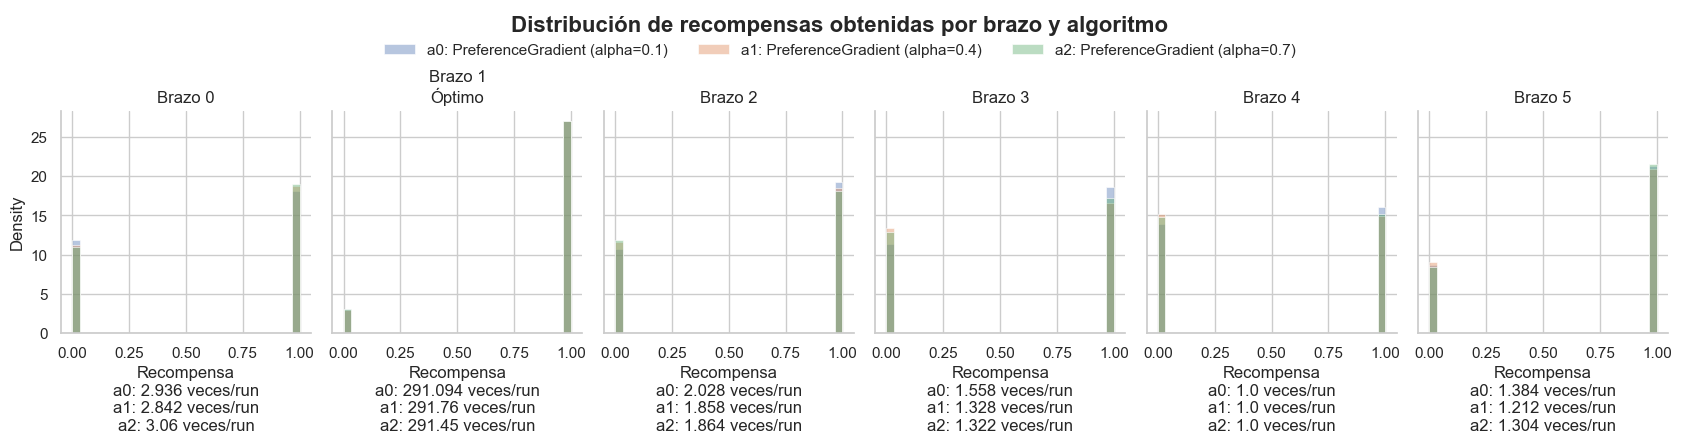

In [39]:
plot_arm_statistics(rewards_per_arm_per_algo_GBe, algorithms_gradient, runs, optimal_arm_bernoulli, kde=False)

## Conclusiones

Comparativa entre algoritmos y demás